In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
from pathlib import Path
import os
import sys
sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv

plt.style.use('../libs/my_style.mplstyle')

#root = Path('/mnt/NAS-Ebanaru/Sasaki/MTsingleBeads')
root = Path('/Volumes/data/Sasaki/MTsingleBeads')

interval = 4

In [ ]:
def plot_mean_velocity(dir, ax, label = None, marker = None):
    df = pd.read_csv(str( dir/'velocities_mean.csv' ))

    ax.plot(df['frame'] * interval, df['mean_velocity'], label=label, marker=marker, markersize=6, linewidth=2, alpha = 0.2)
    ax.set(xlabel = 'Time [s]', ylabel = 'Mean velocity [\u03bcm/s]')

    return df
def plot_mean_velocity_all(root, ax, beads_path, legend = True):
    df_list = []

    for d in glob.glob(str(root / beads_path / "*" / "*")):
        if os.path.isfile(d):
            continue
        df=plot_mean_velocity(Path(d), ax, label = Path(d).name, marker = 'o')
        df_list.append(df)

    df_all = pd.concat(df_list)
    df_v = df_all.groupby('frame').mean().reset_index()

    ax.plot(df_v['frame'] * interval, df_v['mean_velocity'], label='mean', marker='o', markersize=6, linewidth=2, alpha = 1)

    if legend:
        ax.legend()

    return df_v


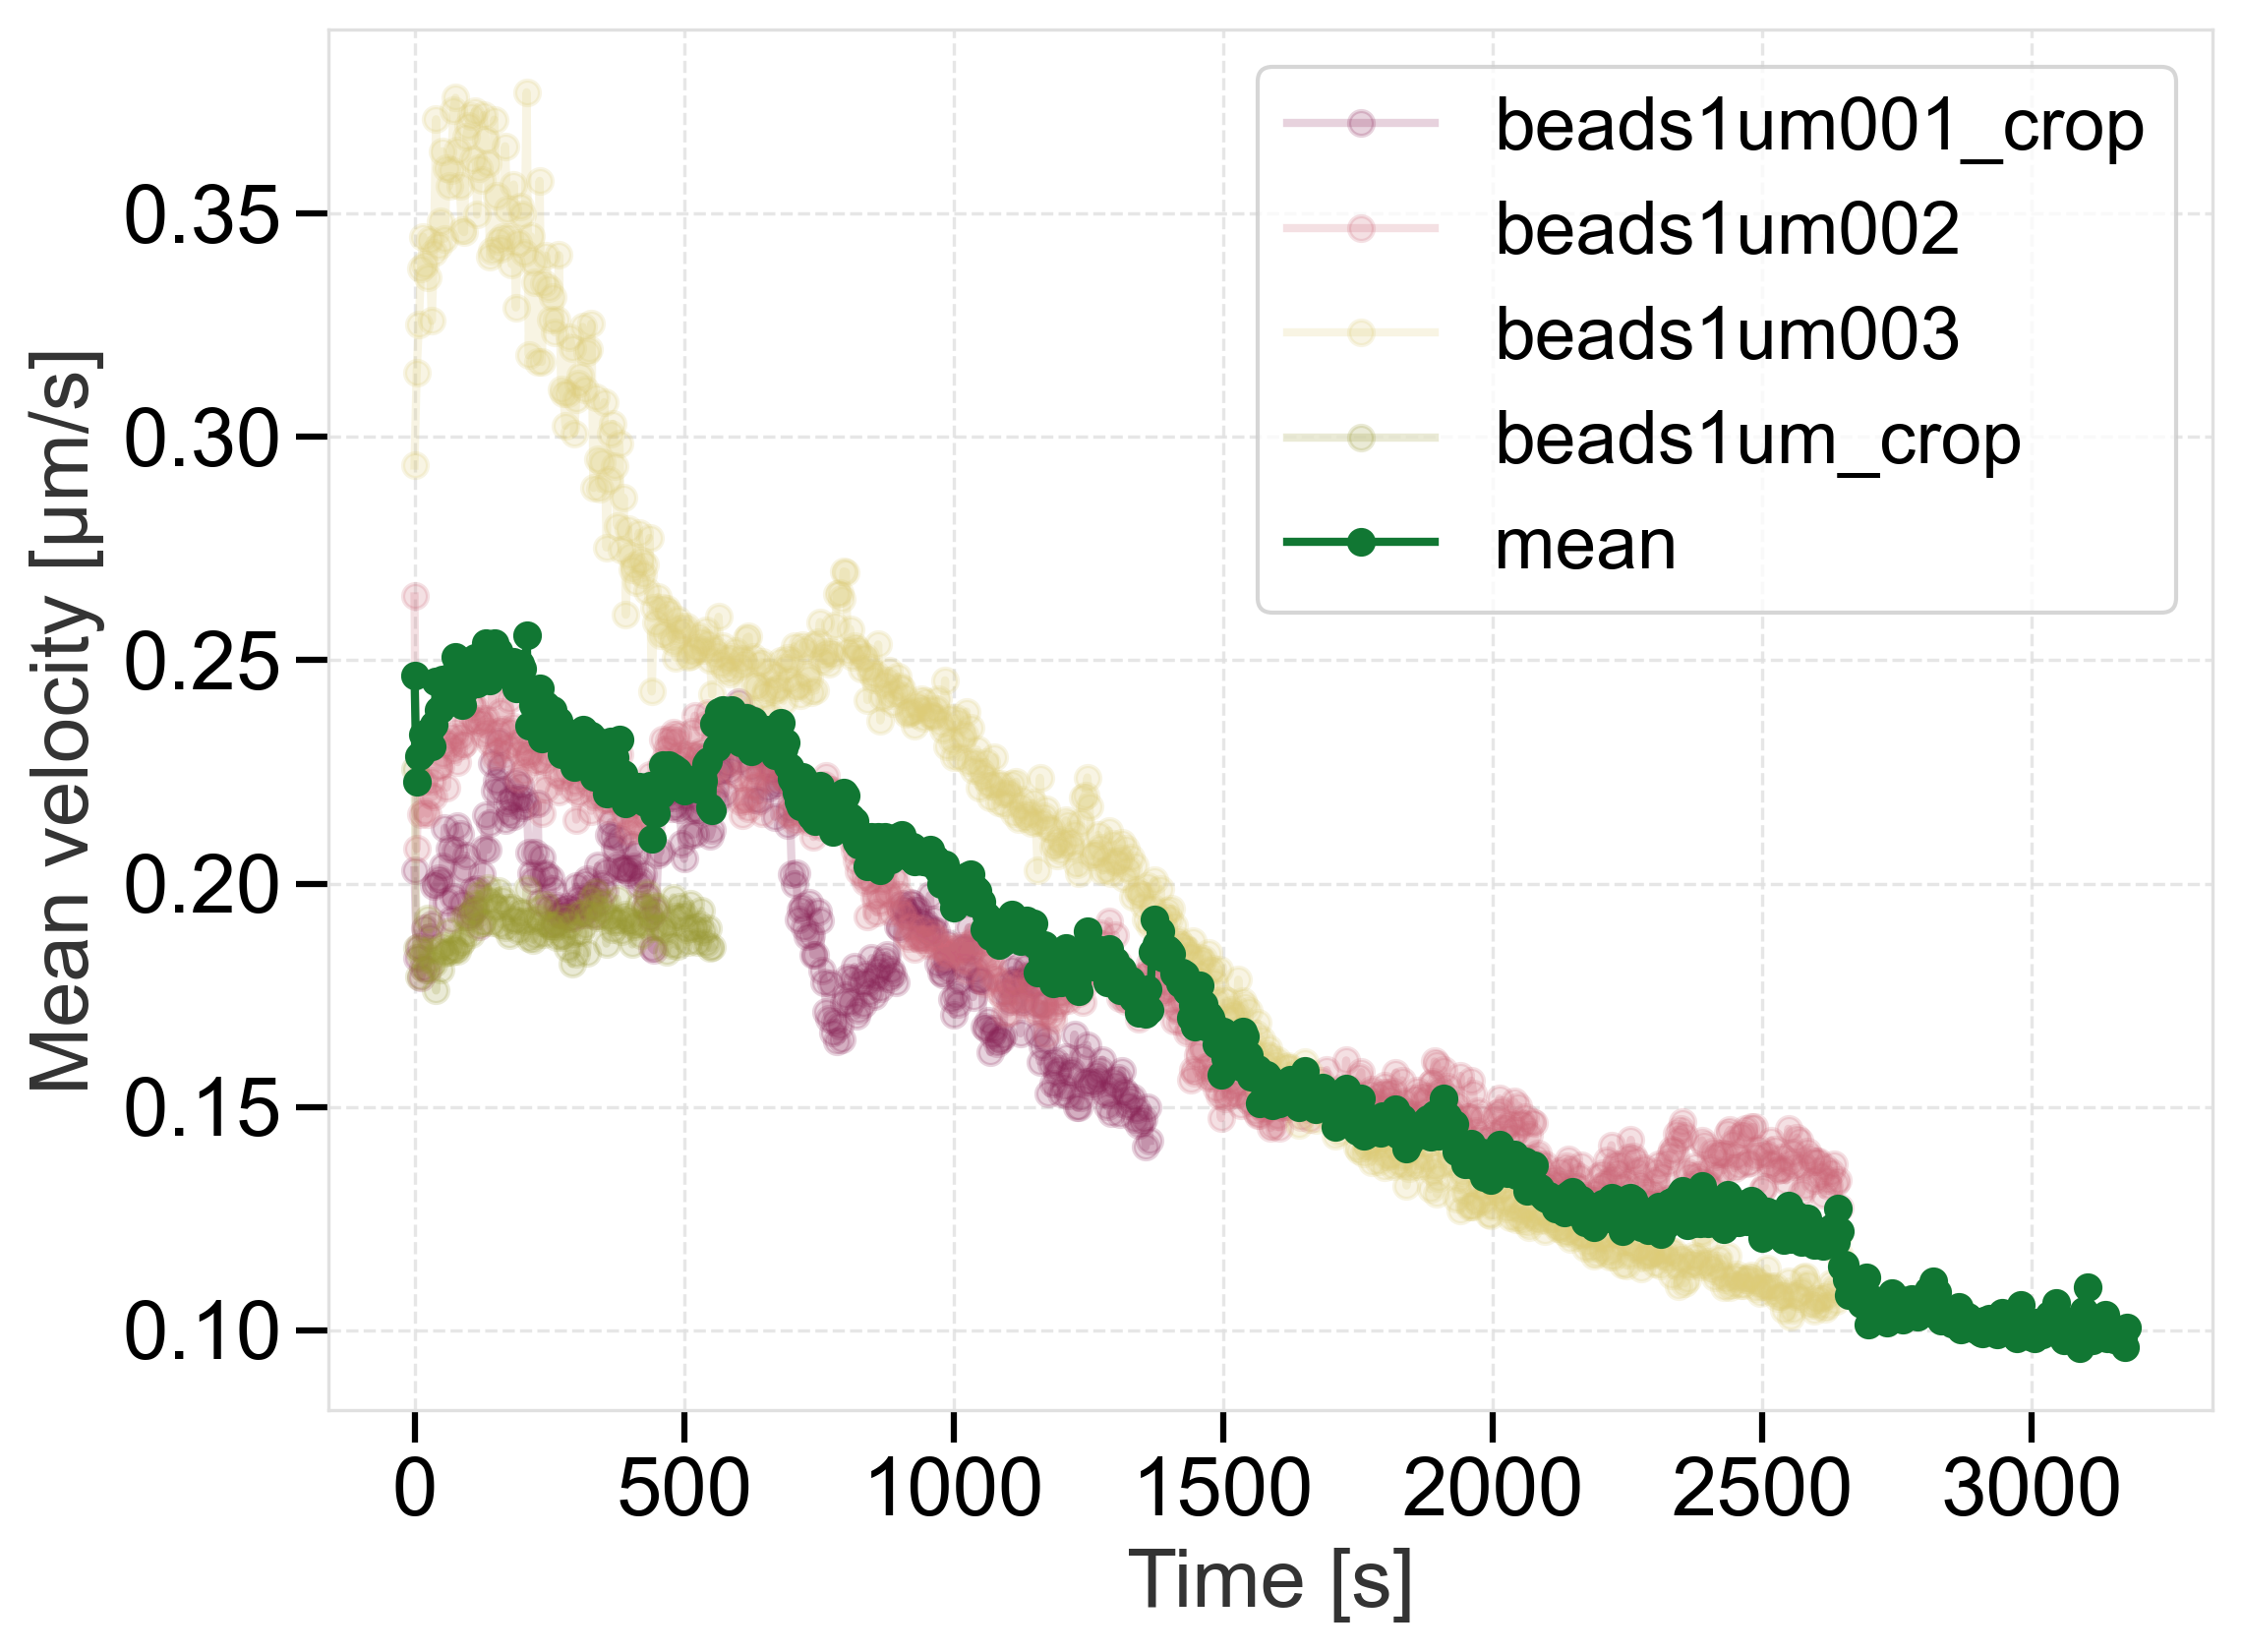

In [3]:
fig, ax = plt.subplots()

df_1um = plot_mean_velocity_all(root, ax, 'beads1um', legend = True)

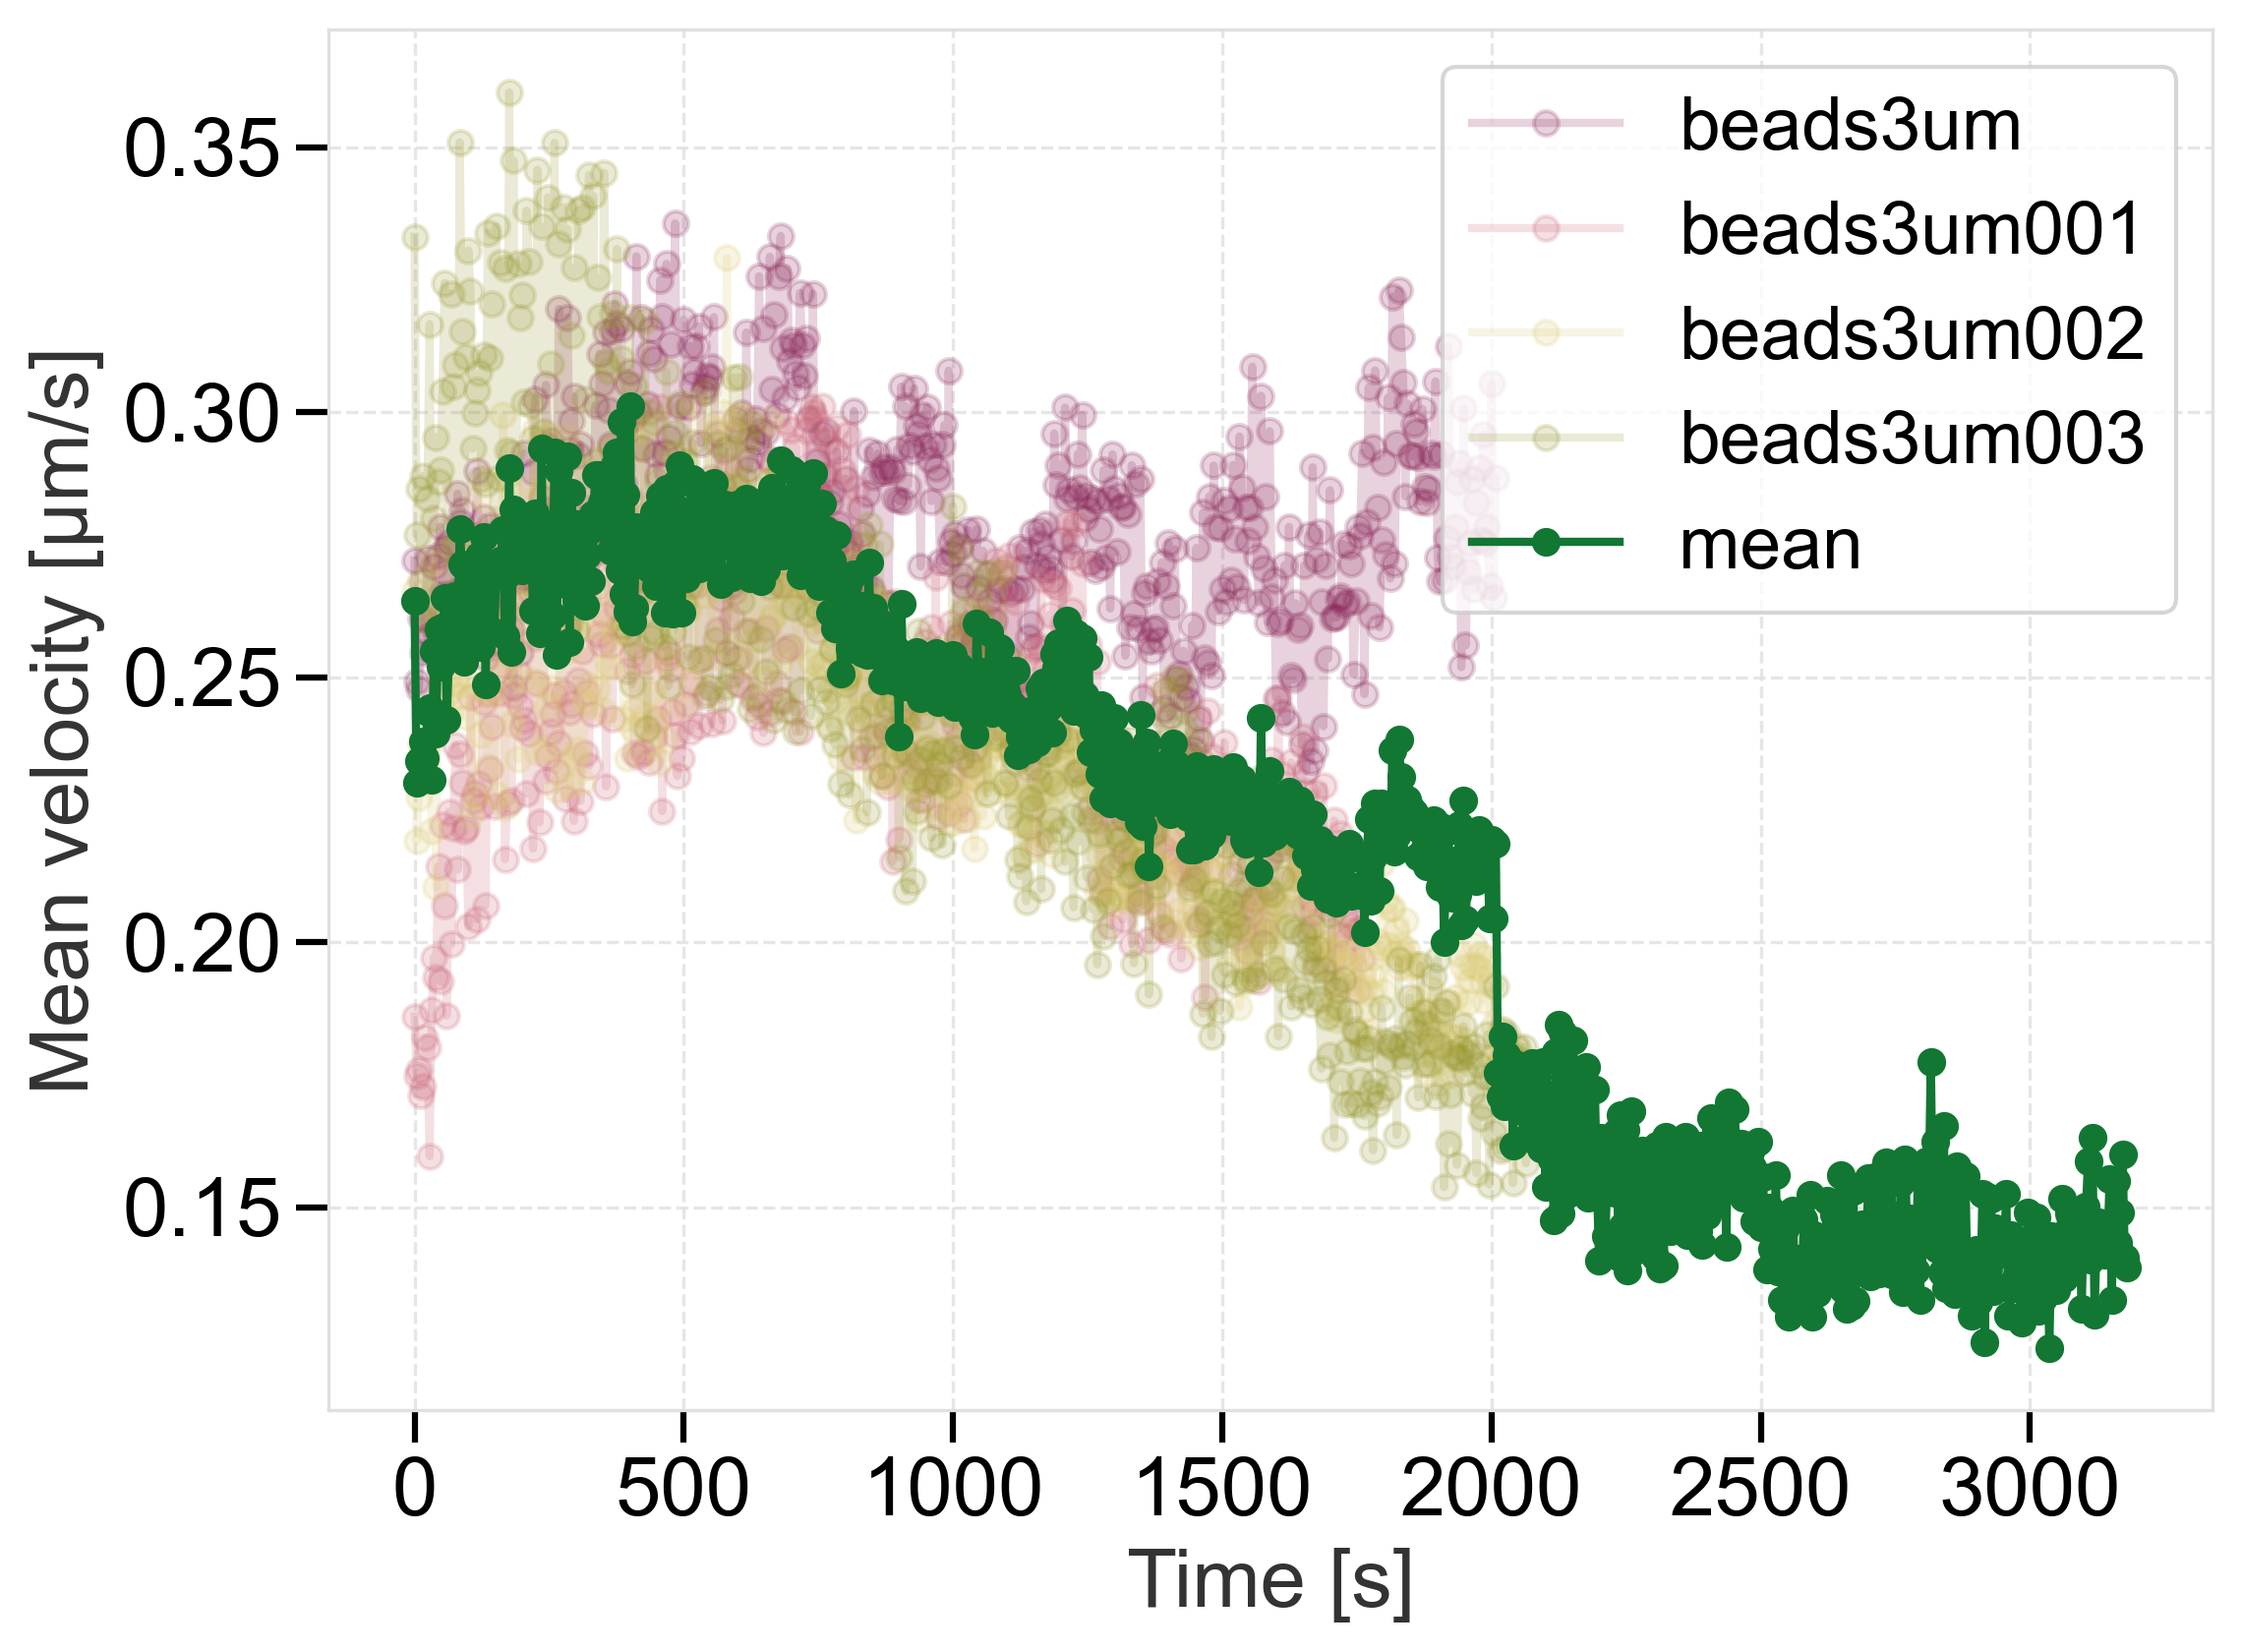

In [4]:
fig, ax = plt.subplots()

df_3um = plot_mean_velocity_all(root, ax, 'beads3um', legend = True)

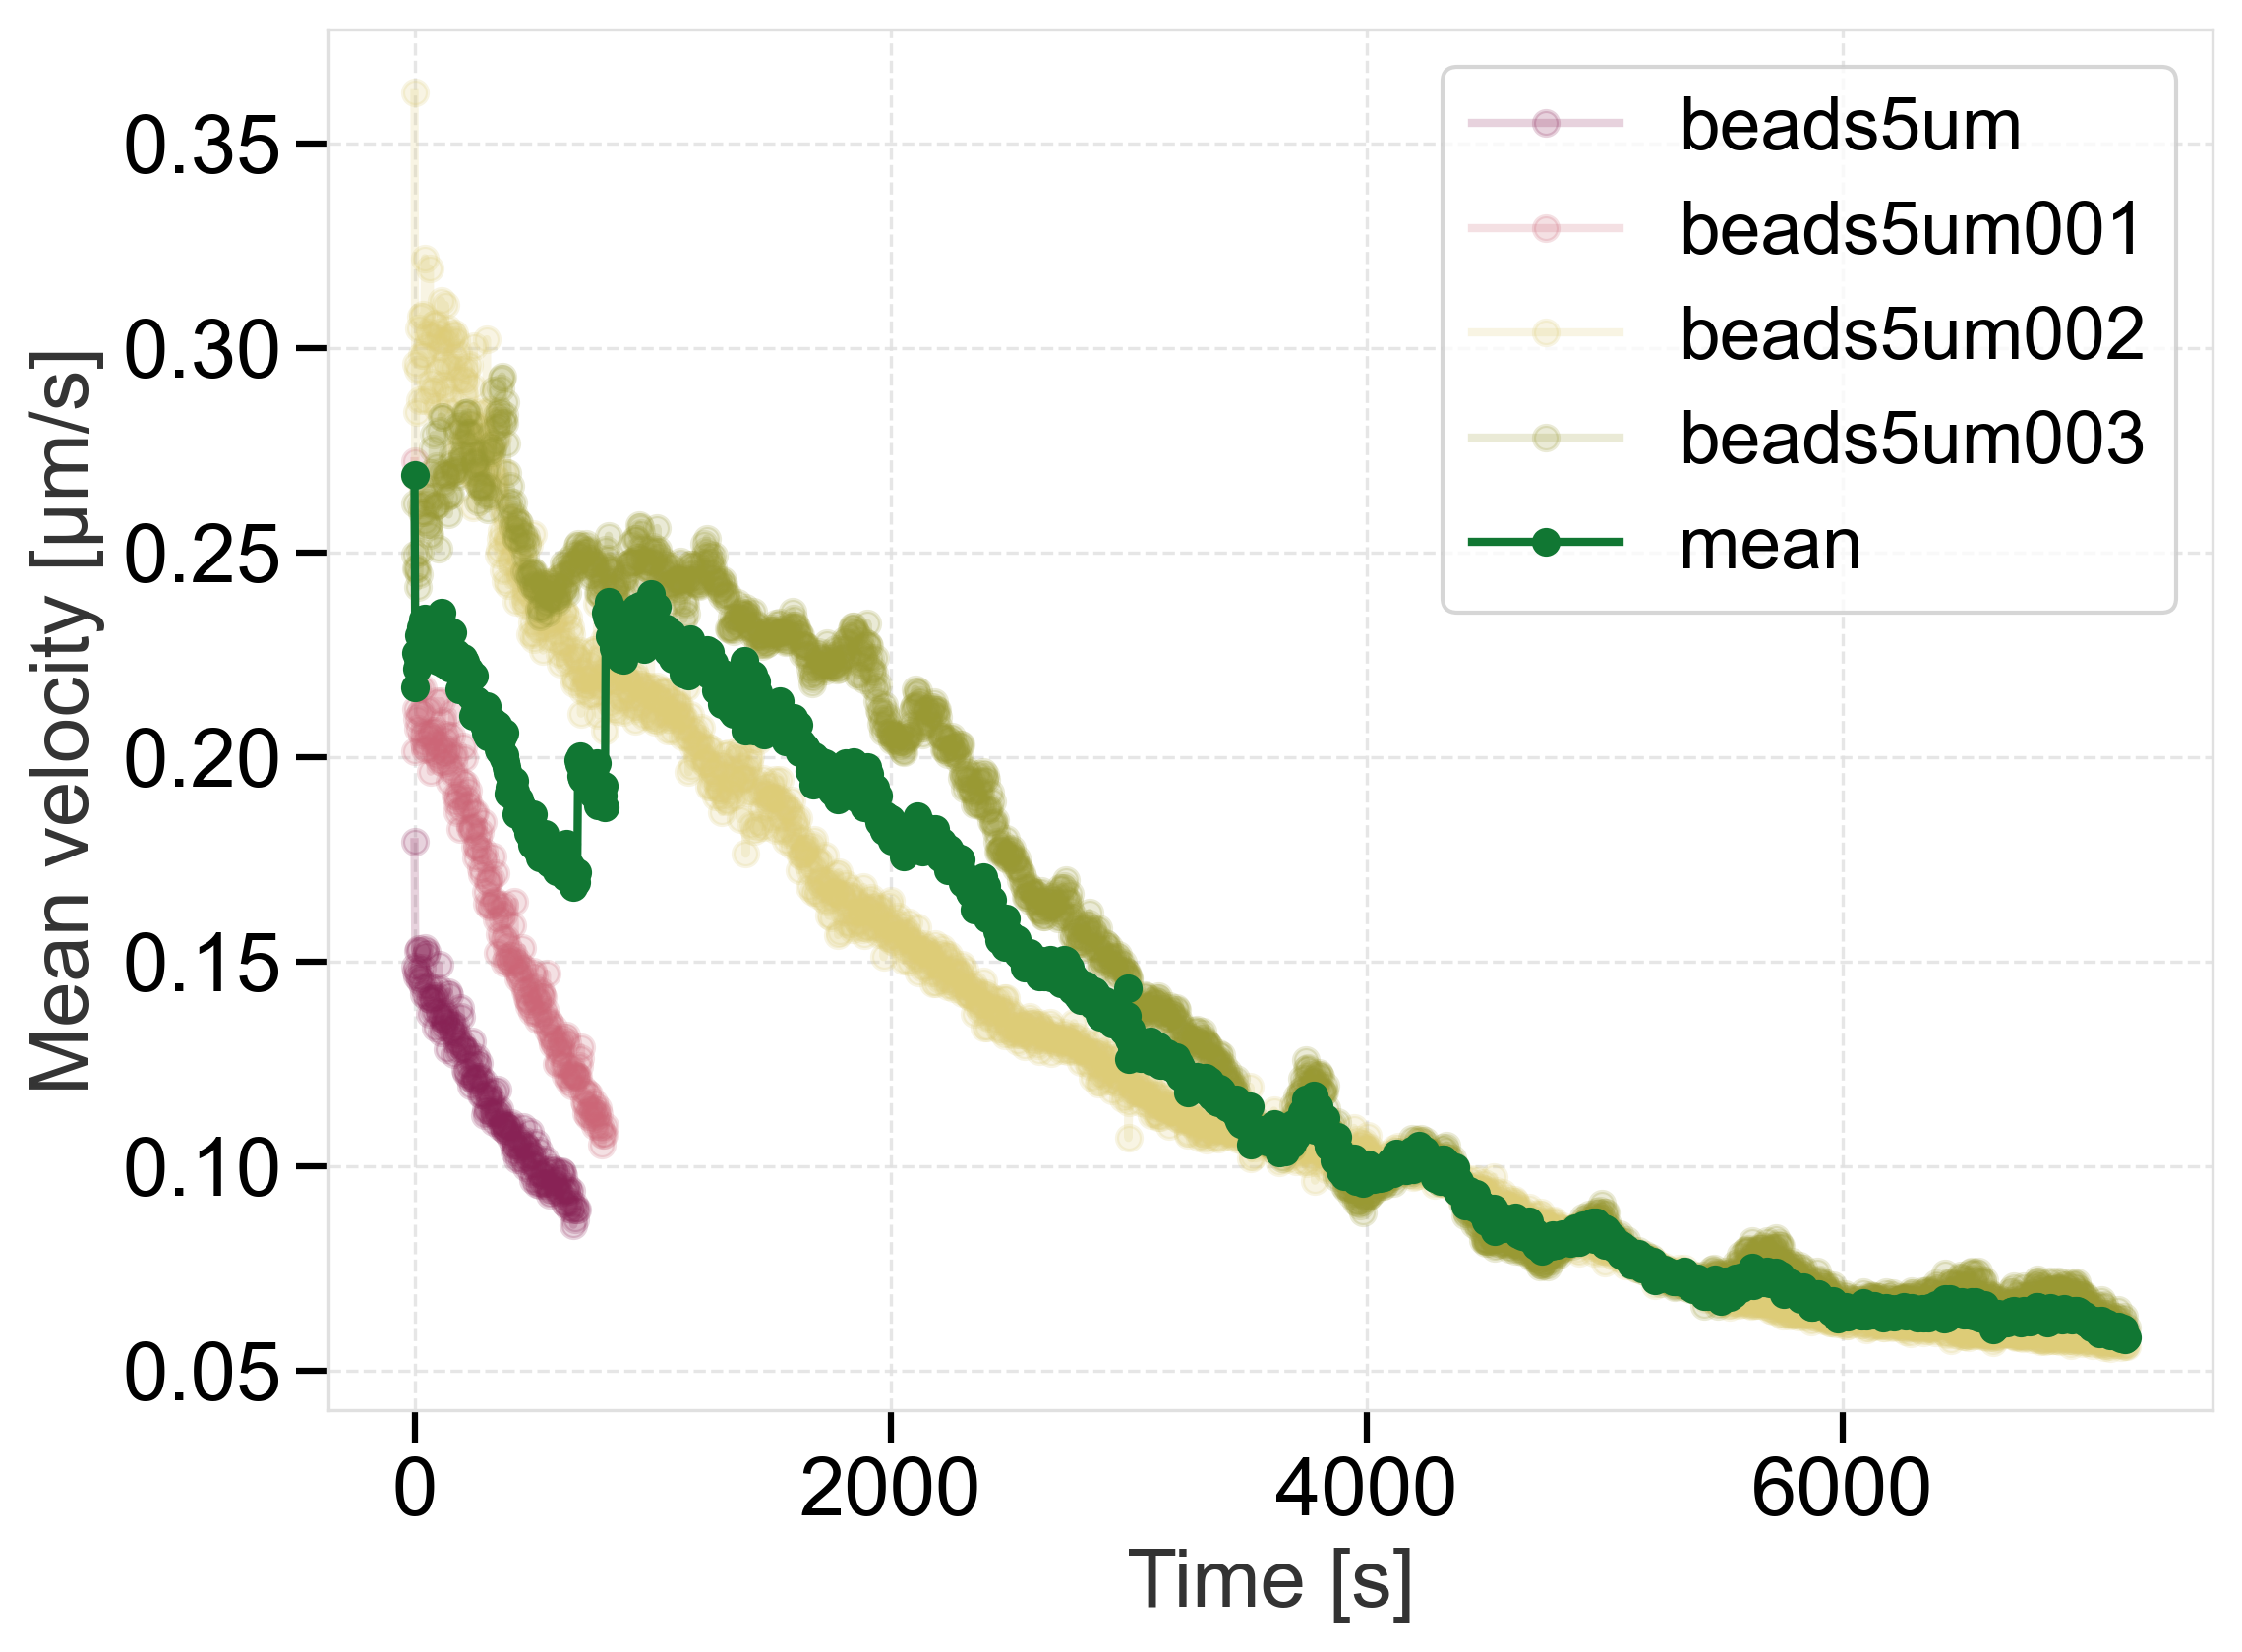

In [5]:
fig, ax = plt.subplots()

df_5um = plot_mean_velocity_all(root, ax, 'beads5um', legend = True)

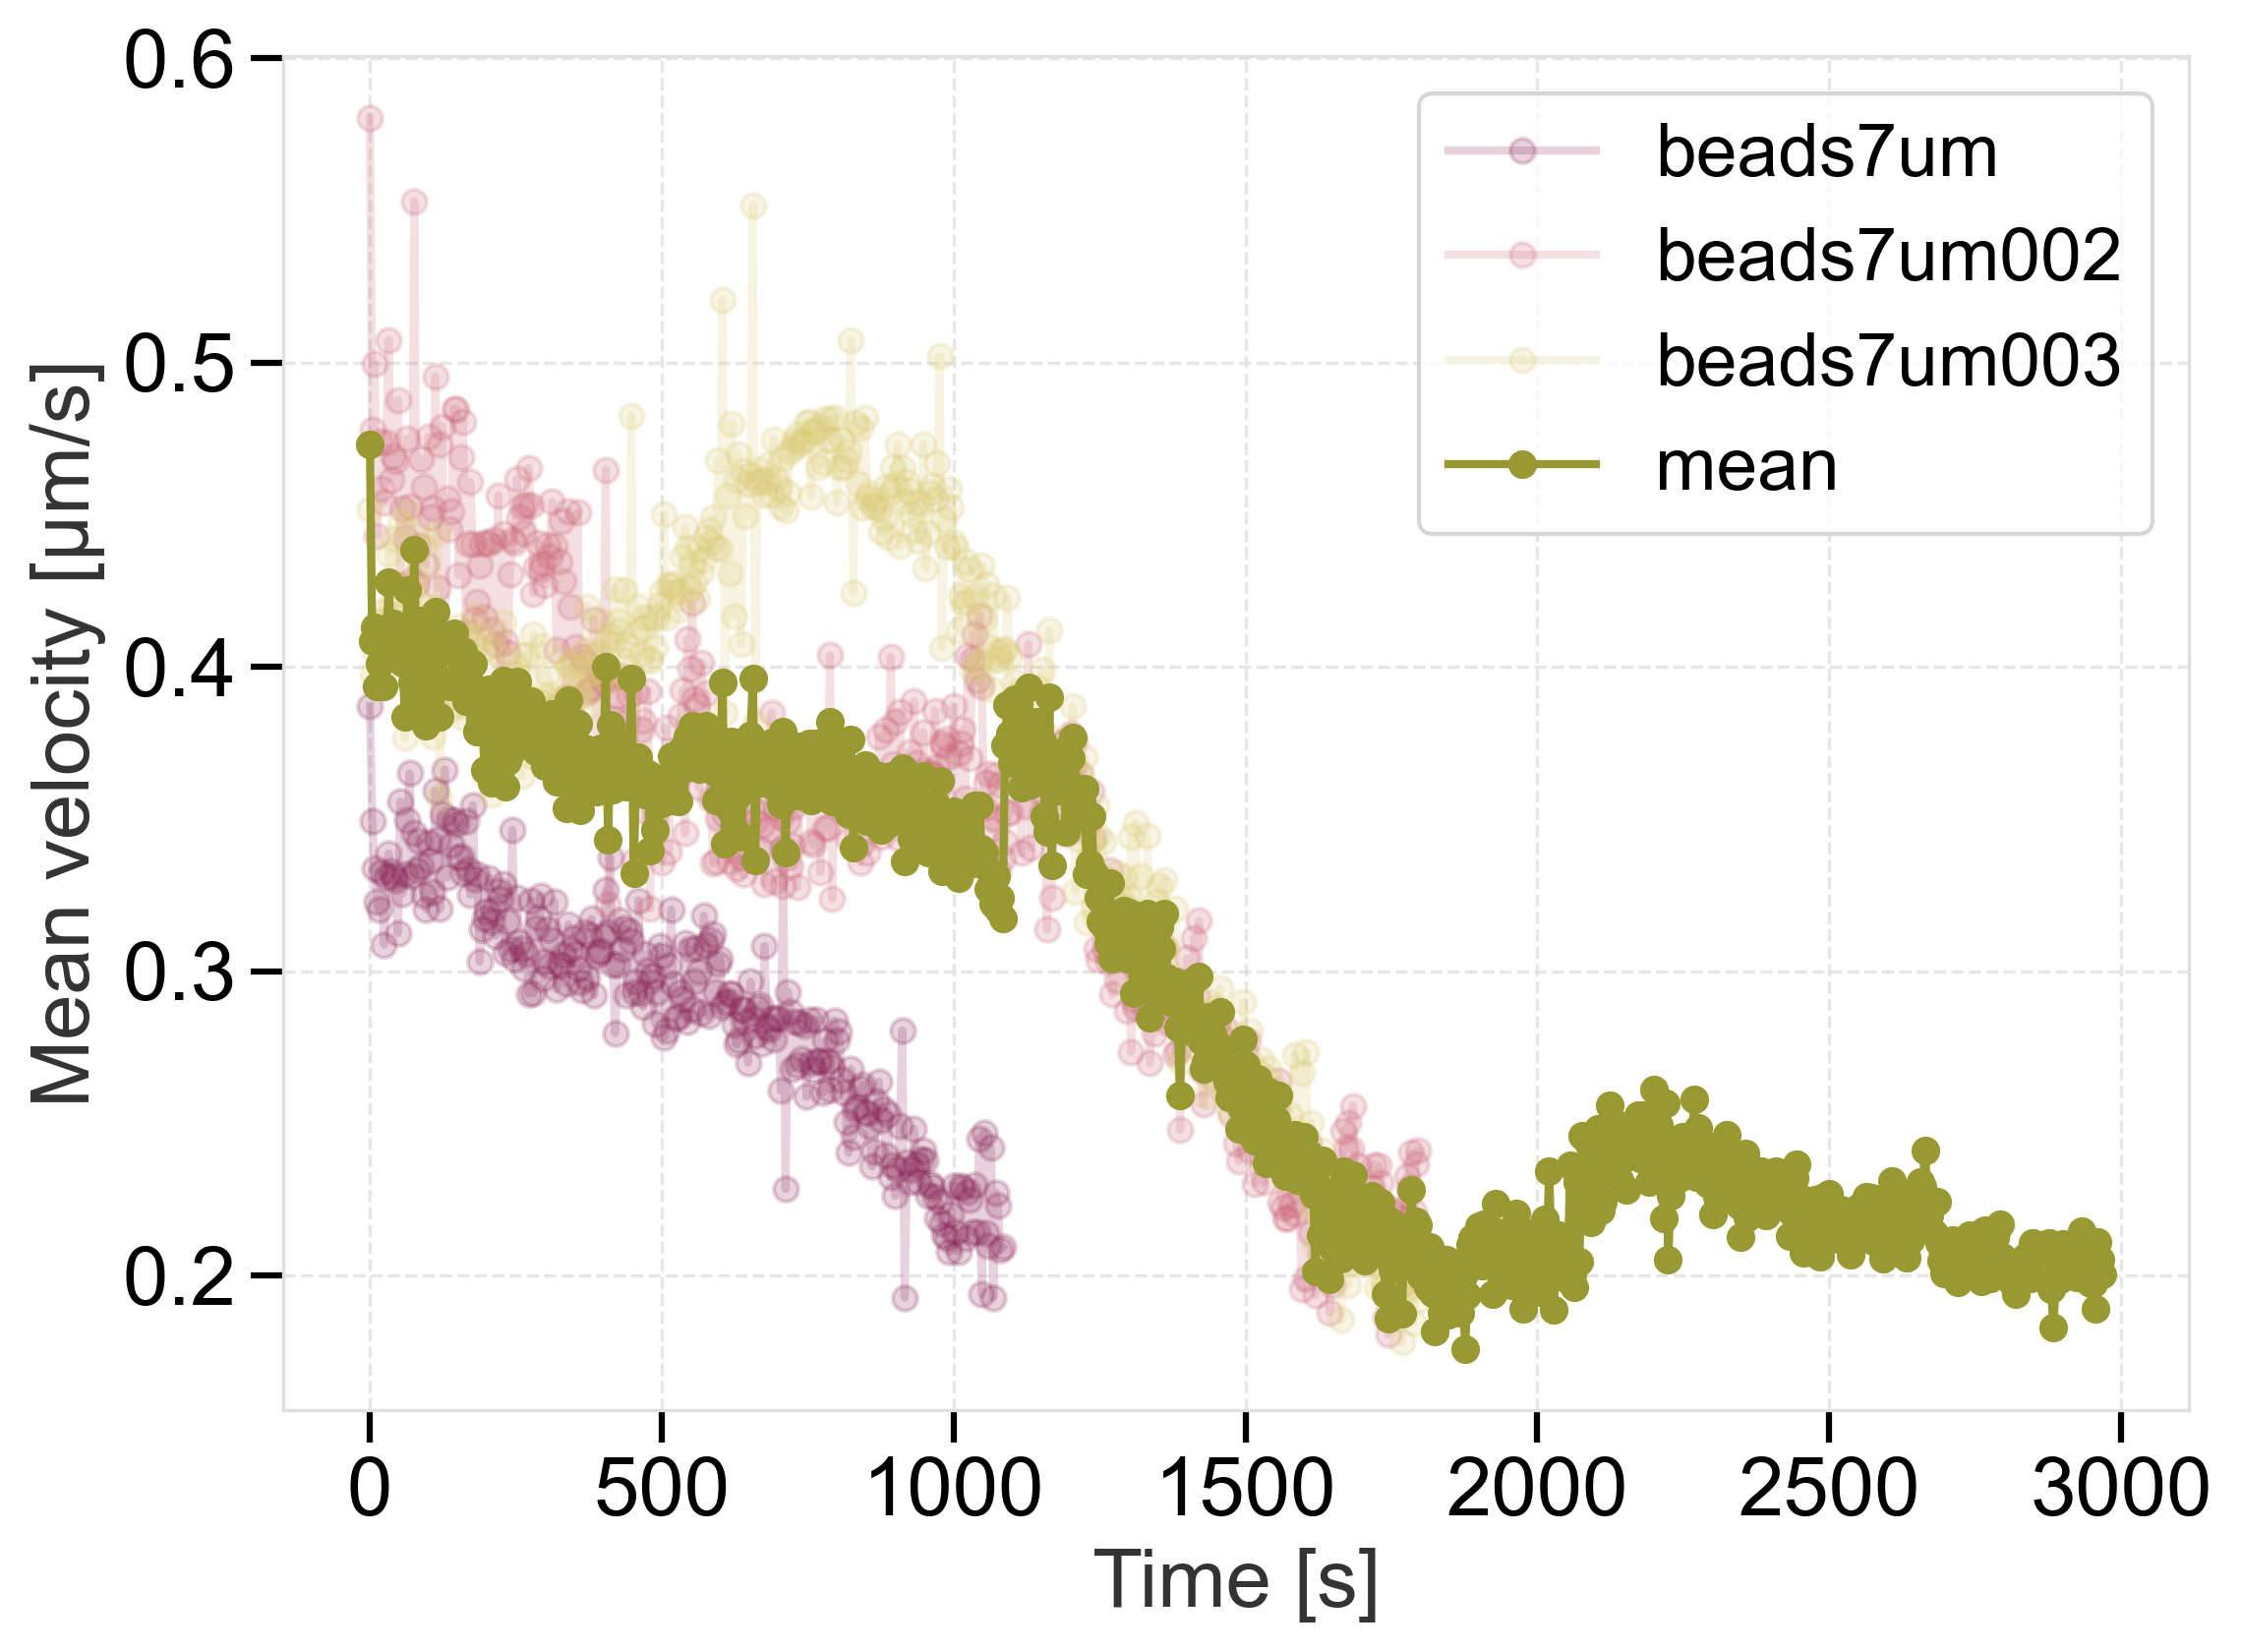

In [6]:
fig, ax = plt.subplots()

df_7um = plot_mean_velocity_all(root, ax, 'beads7um', legend = True)

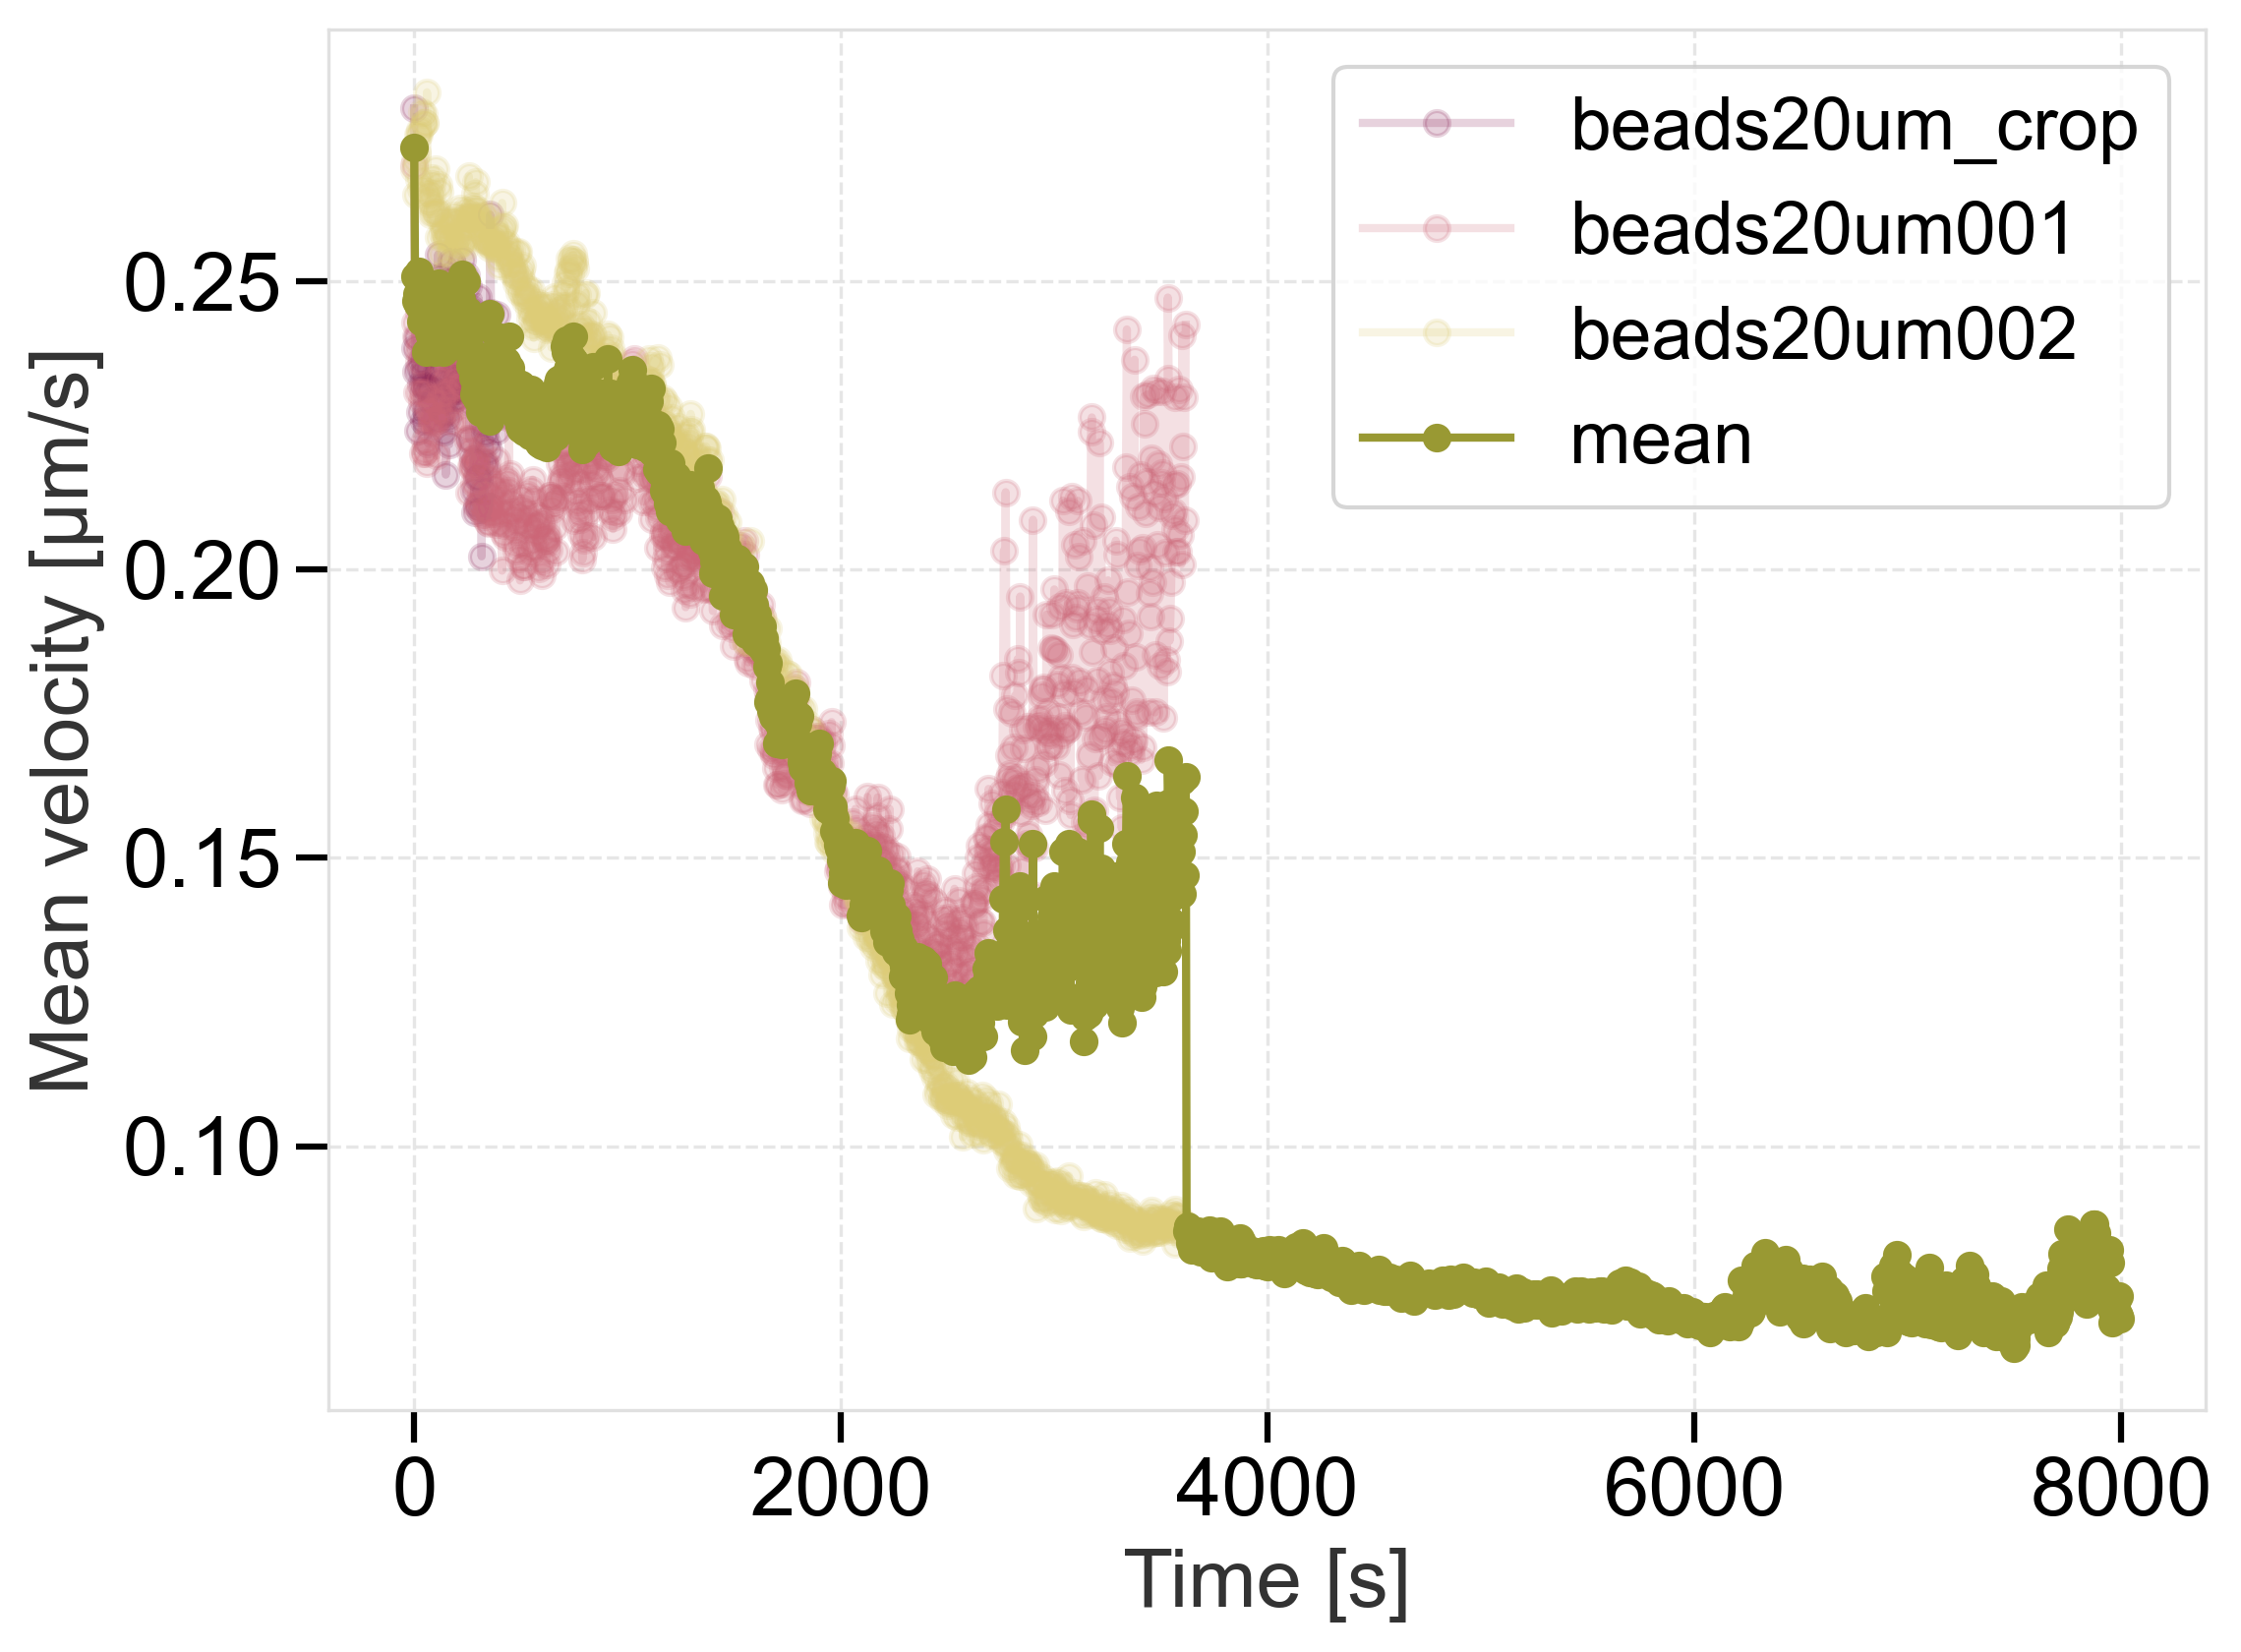

In [8]:
fig, ax = plt.subplots()

df_20um = plot_mean_velocity_all(root, ax, 'beads20um', legend = True)